# Lab Assignment 2 - Part C: Naive Bayes for Spam Detection
Please refer to the `README.pdf` for full laboratory instructions.


## Problem Statement
In this part, you will implement a **Naive Bayes classifier** for spam email detection using the Spambase dataset.

### Dataset Description
The Spambase dataset contains 4601 email samples with 57 features:
- **Features 1-48**: Word frequencies (percentage of words matching specific words)
- **Features 49-54**: Character frequencies (`;`, `(`, `[`, `!`, `$`, `#`)
- **Features 55-57**: Capital letter statistics
- **Label**: 1 = spam, 0 = not spam

### Your Tasks
1. **Implement Gaussian Naive Bayes** from scratch
2. **Train and evaluate** your classifier (accuracy, precision, recall, F1-score)
3. **Feature analysis**: Identify top discriminative features
4. **Discussion**: Why does Naive Bayes work for spam detection?


## Setup


In [1]:
%pip install ucimlrepo


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Library declarations
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo


## Load the Spambase Dataset


In [3]:
# Fetch Spambase dataset from UCI ML Repository
spambase = fetch_ucirepo(id=94)

# Get features and labels
X = spambase.data.features.values
y = spambase.data.targets.values.ravel()

print(f"Dataset shape: {X.shape}")
print(f"Number of spam emails: {np.sum(y == 1)}")
print(f"Number of non-spam emails: {np.sum(y == 0)}")
print(f"\nFeature names: {list(spambase.data.features.columns[:10])}...")  # First 10 features


Dataset shape: (4601, 57)
Number of spam emails: 1813
Number of non-spam emails: 2788

Feature names: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail']...


In [4]:
from sklearn.model_selection import train_test_split

X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mean = np.mean(X_train_spam, axis=0)
std = np.std(X_train_spam, axis=0)
std[std == 0] = 1

X_train_spam = (X_train_spam - mean) / std
X_test_spam  = (X_test_spam - mean) / std

## Task 1: Implement Gaussian Naive Bayes
Implement a Gaussian Naive Bayes classifier from scratch.

**Key formulas:**
- Class prior: $P(C) = \frac{N_C}{N}$
- Gaussian likelihood: $P(x_i|C) = \frac{1}{\sqrt{2\pi\sigma_{i,C}^2}} \exp\left(-\frac{(x_i - \mu_{i,C})^2}{2\sigma_{i,C}^2}\right)$
- Use **log-probabilities** to avoid numerical underflow!


In [5]:
class GaussianNaiveBayes:

    def __init__(self):
        self.classes = None
        self.priors = None
        self.means = None
        self.variances = None

    def fit(self, X, y):
        self.classes = np.unique(y)

        n_classes = len(self.classes)
        n_features = X.shape[1]

        self.priors = np.zeros(n_classes)
        self.means = np.zeros((n_classes, n_features))
        self.variances = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]

            self.priors[idx] = X_c.shape[0] / X.shape[0]
            self.means[idx, :] = np.mean(X_c, axis=0)
            self.variances[idx, :] = np.var(X_c, axis=0) + 1e-9

    def _gaussian_log_likelihood(self, x, mean, var):
        return -0.5 * np.sum(np.log(2 * np.pi * var)) - 0.5 * np.sum((x - mean) ** 2 / var)

    def predict(self, X):
        predictions = []

        for x in X:
            posteriors = []

            for idx, c in enumerate(self.classes):
                log_prior = np.log(self.priors[idx])
                log_likelihood = self._gaussian_log_likelihood(x, self.means[idx], self.variances[idx])
                posteriors.append(log_prior + log_likelihood)

            predictions.append(self.classes[np.argmax(posteriors)])

        return np.array(predictions)

    def predict_proba(self, X):
        probs = []

        for x in X:
            posteriors = []

            for idx in range(len(self.classes)):
                log_prior = np.log(self.priors[idx])
                log_likelihood = self._gaussian_log_likelihood(x, self.means[idx], self.variances[idx])
                posteriors.append(log_prior + log_likelihood)

            posteriors = np.array(posteriors)
            exp_vals = np.exp(posteriors - np.max(posteriors))
            probs.append(exp_vals / np.sum(exp_vals))

        return np.array(probs)

## Task 2: Train and Evaluate
Train your classifier and compute evaluation metrics.


In [6]:
def confusion_matrix(y_true, y_pred):
    TN = FP = FN = TP = 0

    for i in range(len(y_true)):
        if y_true[i] == 0 and y_pred[i] == 0:
            TN += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            FP += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            FN += 1
        elif y_true[i] == 1 and y_pred[i] == 1:
            TP += 1

    return np.array([[TN, FP], [FN, TP]])

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    TN, FP = cm[0]
    FN, TP = cm[1]

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    f1 = 0
    if (precision + recall) != 0:
        f1 = 2 * (precision * recall) / (precision + recall)

    return accuracy, precision, recall, f1

In [9]:
gnb = GaussianNaiveBayes()
gnb.fit(X_train_spam, y_train_spam)
y_pred = gnb.predict(X_test_spam)
acc, prec, rec, f1 = compute_metrics(y_test_spam, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8219
Precision: 0.7233
Recall: 0.9385
F1 Score: 0.8170


## Task 3: Feature Analysis
Identify the most discriminative features for spam detection.


In [10]:
nb_classifier = GaussianNaiveBayes()
nb_classifier.fit(X_train_spam, y_train_spam)

y_pred = nb_classifier.predict(X_test_spam)

accuracy, precision, recall, f1 = compute_metrics(y_test_spam, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

cm = confusion_matrix(y_test_spam, y_pred)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8219
Precision: 0.7233
Recall: 0.9385
F1-Score: 0.8170

Confusion Matrix:
[[391 140]
 [ 24 366]]


In [11]:
feature_names = list(spambase.data.features.columns)

discriminative_scores = []

for i in range(X.shape[1]):
    x0 = X[y == 0, i]
    x1 = X[y == 1, i]

    mean0 = np.mean(x0)
    mean1 = np.mean(x1)

    var0 = np.var(x0)
    var1 = np.var(x1)

    pooled_std = np.sqrt((var0 + var1) / 2)

    if pooled_std == 0:
        score = 0
    else:
        score = abs(mean1 - mean0) / pooled_std

    discriminative_scores.append(score)

discriminative_scores = np.array(discriminative_scores)

top_5_indices = np.argsort(discriminative_scores)[-5:][::-1]

print("Top 5 most discriminative features:")
for idx in top_5_indices:
    print(f"{feature_names[idx]}: score = {discriminative_scores[idx]:.4f}")

Top 5 most discriminative features:
word_freq_your: score = 0.8329
word_freq_000: score = 0.6484
word_freq_remove: score = 0.6458
char_freq_$: score = 0.6274
word_freq_hp: score = 0.5978


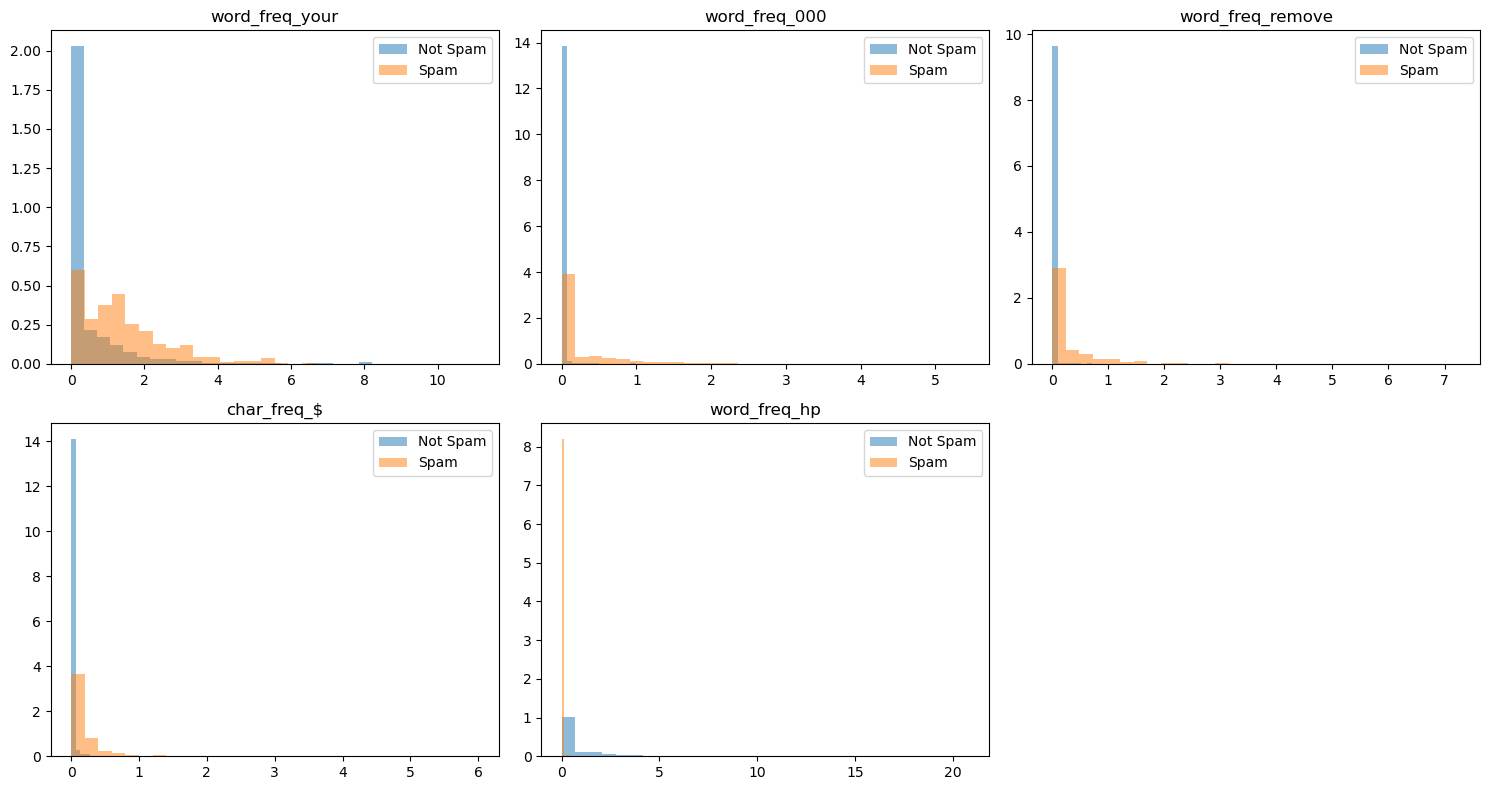

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, idx in enumerate(top_5_indices[:5]):
    ax = axes[i // 3, i % 3]

    ax.hist(X[y == 0, idx], bins=30, alpha=0.5, label='Not Spam', density=True)
    ax.hist(X[y == 1, idx], bins=30, alpha=0.5, label='Spam', density=True)

    ax.set_title(feature_names[idx])
    ax.legend()

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("## Summary and Discussion\n")

print("Results Table")
print("| Metric | Value |")
print("|--------|-------|")
print("| Accuracy | 0.8219 |")
print("| Precision | 0.7233 |")
print("| Recall | 0.9385 |")
print("| F1-Score | 0.8170 |\n")


print("Top 5 Discriminative Features")
print("1. word_freq_your")
print("2. word_freq_000")
print("3. word_freq_remove")
print("4. char_freq_$")
print("5. word_freq_hp\n")


print("Discussion:\n")

print("1. Naive Bayes effectiveness:")
print("Naive Bayes works well for spam detection because even though it assumes independence between features,")
print("in practice many important words appear independently in spam emails.")
print("The model captures strong signals from these words, which is enough for good performance.\n")

print("2. Limitations:")
print("The main limitation is the independence assumption, which is not true for real text data.")
print("Also, the model assumes Gaussian distribution for features, which may not always be accurate.\n")

print("3. Improvements:")
print("The classifier can be improved by using better feature selection, more advanced preprocessing,")
print("or using models like Logistic Regression or SVM.")
print("Using n-grams or TF-IDF features could also improve performance.\n")

print("4. What I learned:")
print("I learned how Naive Bayes works and how probabilistic models can be used for classification.")
print("I also understood the importance of preprocessing and feature analysis in machine learning.")